In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import calendar

# Data Loading and preprocessing

In [2]:
# Load the data
file_path = 'PoisonedOnly_NEISS_2004-2023.xlsx'
print(f"Loading data from {file_path}...")
df = pd.read_excel(file_path, sheet_name='ALL (DO NOT EDIT)', dtype=str)

Loading data from PoisonedOnly_NEISS_2004-2023.xlsx...


In [3]:
# Data preprocessing

# Convert weights to numeric
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')

# Create a new categorical column for vitamins
vitamin_codes = ['1927', '1931', '1932']
df['Category'] = np.where(df['Product_1'].isin(vitamin_codes), 'Vitamins', 'Other Exposures')

# Convert Treatment_Date to actual datetime objects
df['Treatment_Date'] = pd.to_datetime(df['Treatment_Date'], errors='coerce')
df['Year'] = df['Treatment_Date'].dt.year
df['Month'] = df['Treatment_Date'].dt.month
df = df.dropna(subset=['Year', 'Month'])
df['Year'] = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)

# Drop rows with invalid dates
df = df.dropna(subset=['Treatment_Date'])

# YEARLY DATA
# Group by Year and Category, then unstack to create two columns ('Vitamins' and 'Other Exposures')
yearly_data = df.groupby(['Year', 'Category'])['Weight'].sum().unstack(fill_value=0)

# QUARTERLY DATA
# Create a continuous Year-Quarter column (e.g., Q1 2004, Q2 2004)
# .dt.to_period('Q') converts dates to the correct fiscal quarter
# .dt.to_timestamp() converts it back to the first day of that quarter (e.g., Jan 1st, Apr 1st) for plotting
df['YearQuarter'] = df['Treatment_Date'].dt.to_period('Q').dt.to_timestamp()
quarterly_data = df.groupby(['YearQuarter', 'Category'])['Weight'].sum().unstack(fill_value=0)


# INDEXED DATA (Base Year = 100)
# Identify the earliest year to use as the baseline (Index = 100)
base_year = yearly_data.index.min()
# Divide all years by the base year's value and multiply by 100
indexed_data = yearly_data.div(yearly_data.loc[base_year]) * 100


# NORMALIZED SEASONALITY CALCULATION ---

# 1) Sum total ED visits for each specific Month of each Year
monthly_yearly_data = df.groupby(['Year', 'Month', 'Category'])['Weight'].sum().reset_index()

# 2) Sum total ED visits for the entire Year
yearly_totals = monthly_yearly_data.groupby(['Year', 'Category'])['Weight'].sum().reset_index()
yearly_totals = yearly_totals.rename(columns={'Weight': 'Year_Total'})

# 3) Merge and calculate the percentage share that each month contributes to its year
merged_data = pd.merge(monthly_yearly_data, yearly_totals, on=['Year', 'Category'])
merged_data['Month_Share_Pct'] = (merged_data['Weight'] / merged_data['Year_Total']) * 100

# 4) Average these monthly percentages across all 20 years
final_seasonality = merged_data.groupby(['Month', 'Category'])['Month_Share_Pct'].mean().unstack()


# Trend Analysis

#### Absolute Yearly Trend

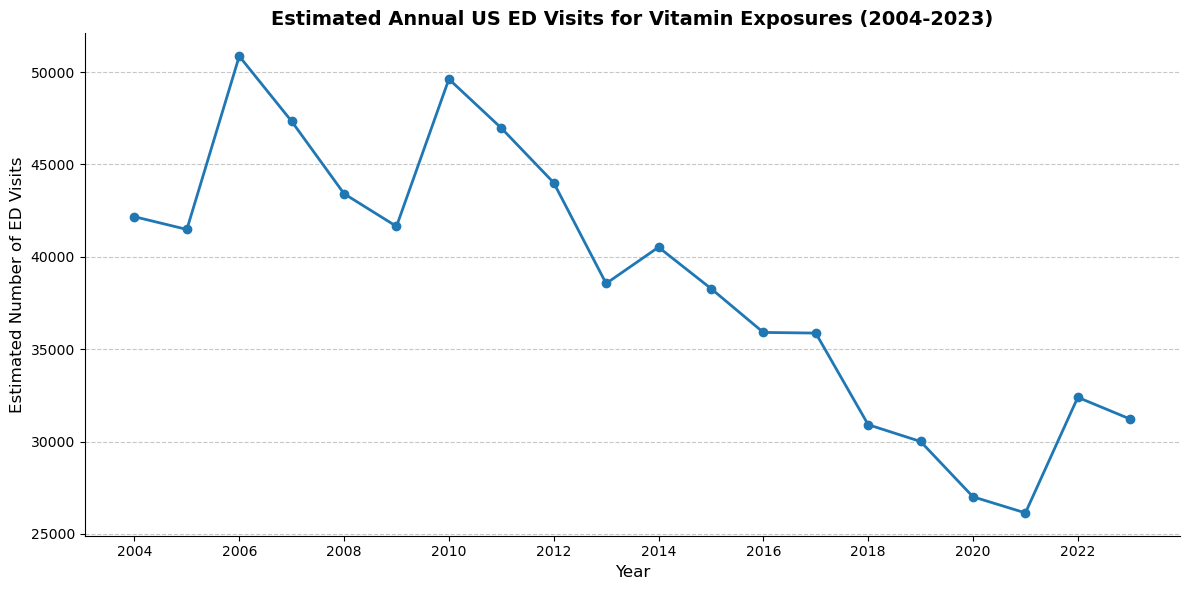

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(yearly_data.index, yearly_data['Vitamins'], 
         marker='o', linestyle='-', linewidth=2, color='#1f77b4', markersize=6)

plt.title('Estimated Annual US ED Visits for Vitamin Exposures (2004-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Estimated Number of ED Visits', fontsize=12)
plt.xticks(np.arange(min(yearly_data.index), max(yearly_data.index)+1, 2))
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

#### Comparative Yearly Trend

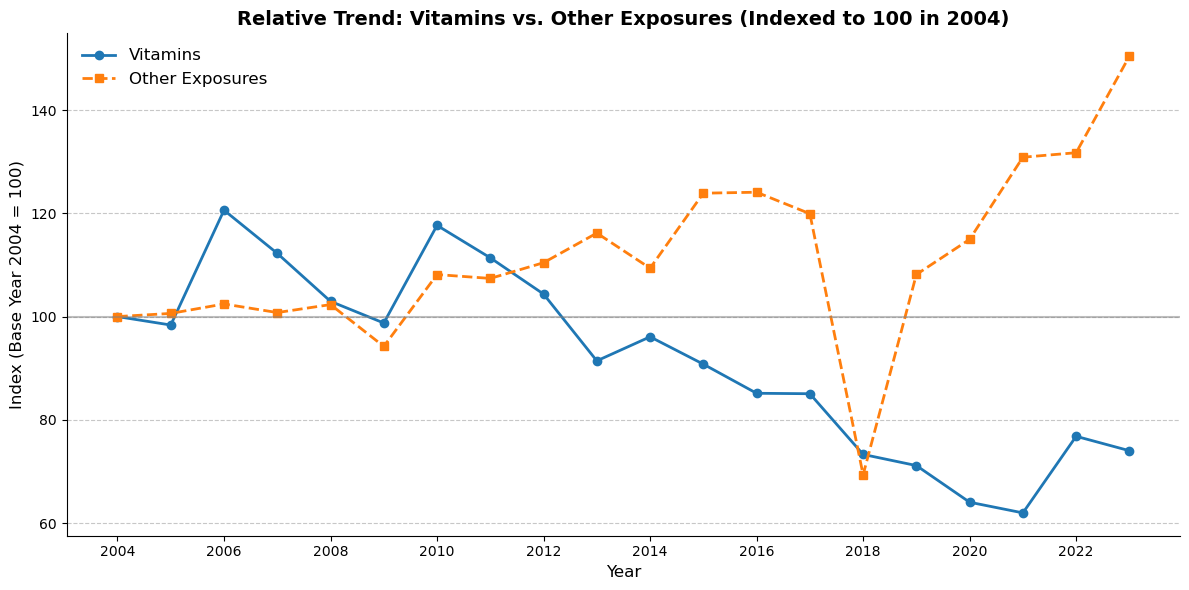

In [5]:
plt.figure(figsize=(12, 6))

# Plot both indexed trends on the same scale
plt.plot(indexed_data.index, indexed_data['Vitamins'], 
         marker='o', linestyle='-', linewidth=2, color='#1f77b4', markersize=6, label='Vitamins')
plt.plot(indexed_data.index, indexed_data['Other Exposures'], 
         marker='s', linestyle='--', linewidth=2, color='#ff7f0e', markersize=6, label='Other Exposures')

plt.title('Relative Trend: Vitamins vs. Other Exposures (Indexed to 100 in 2004)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Index (Base Year 2004 = 100)', fontsize=12)
plt.xticks(np.arange(min(indexed_data.index), max(indexed_data.index)+1, 2))

# Add a horizontal line at 100 to visually separate growth from decline
plt.axhline(y=100, color='gray', linestyle='-', alpha=0.5)

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.legend(frameon=False, fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

#### Quarterly Trend

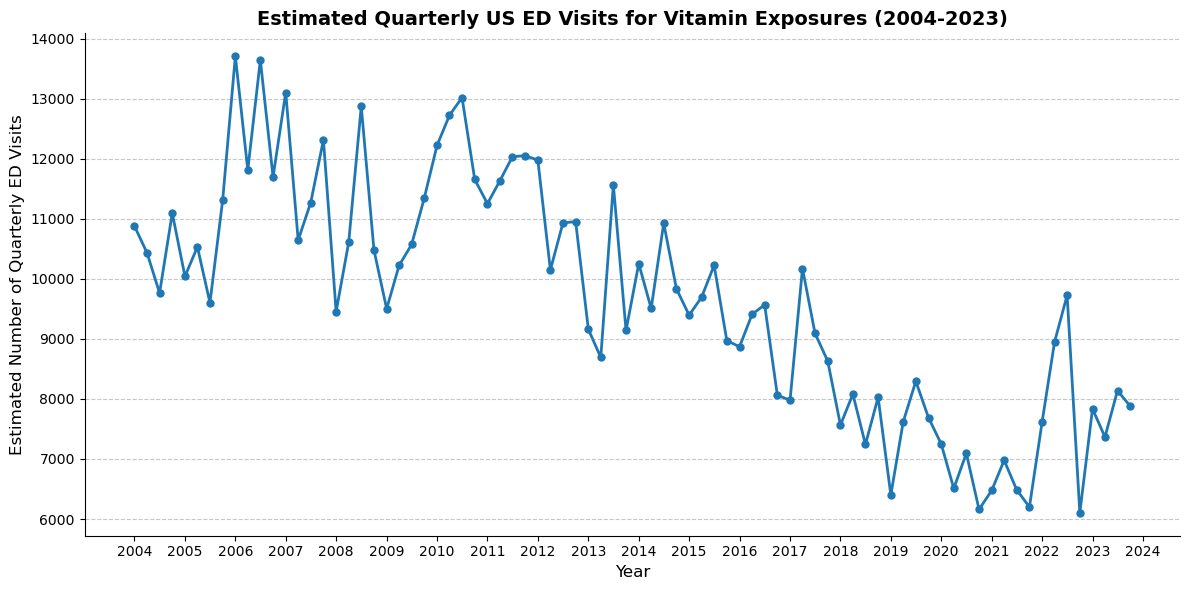

In [6]:
plt.figure(figsize=(12, 6))

plt.plot(quarterly_data.index, quarterly_data['Vitamins'], 
         marker='o', linestyle='-', linewidth=2, color='#1f77b4', markersize=5)

plt.title('Estimated Quarterly US ED Visits for Vitamin Exposures (2004-2023)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Estimated Number of Quarterly ED Visits', fontsize=12)

# Format the X-axis to show a tick for every single year cleanly
plt.gca().xaxis.set_major_locator(mdates.YearLocator(1)) 
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

# Seasonality Analysis

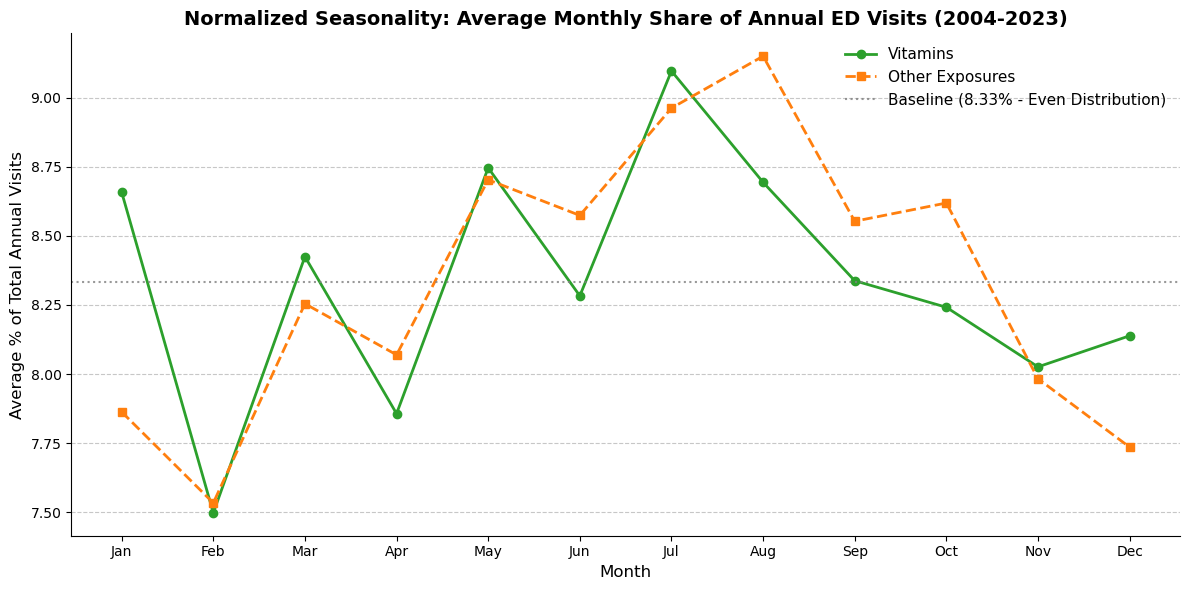

In [ ]:
plt.figure(figsize=(12, 6))

# Plot Vitamins
plt.plot(final_seasonality.index, final_seasonality['Vitamins'], 
         marker='o', color='#2ca02c', linewidth=2, label='Vitamins')

# Plot Other Exposures
plt.plot(final_seasonality.index, final_seasonality['Other Exposures'], 
         marker='s', linestyle='--', color='#ff7f0e', linewidth=2, label='Other Exposures')

# Formatting
plt.title('Normalized Seasonality: Average Monthly Share of Annual ED Visits (2004-2023)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average % of Total Annual Visits', fontsize=12)

# Set X-axis to display month names properly using the 'calendar' library
plt.xticks(ticks=range(1, 13), labels=calendar.month_abbr[1:13])

# Add a baseline horizontal line (100% / 12 months = 8.33%)
plt.axhline(y=100/12, color='gray', linestyle=':', alpha=0.8, 
            label='Baseline (8.33% - Even Distribution)')

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.legend(frameon=False, fontsize=11)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()